<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/one_way_and_two_way_anova.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
from math import sqrt
from scipy.stats import norm

# Given values
n = 40               # Sample size
x_bar = 495          # Sample mean
mu = 500             # Population mean
sigma = 10           # Population standard deviation
alpha = 0.01         # Significance level

# Compute the Z-value
z_value = (x_bar - mu) / (sigma / sqrt(n))

# Compute the p-value for a one-tailed test
p_value = norm.cdf(z_value)  # CDF gives the area to the left of Z

# Decision rule using p-value
if p_value < alpha:
    print("Reject the null hypothesis: The machine is underfilling bottles.")
else:
    print("Fail to reject the null hypothesis: No evidence of underfilling.")

# Output the Z-value and p-value
print("Z-value:", z_value)
print("P-value:", p_value)


Reject the null hypothesis: The machine is underfilling bottles.
Z-value: -3.1622776601683795
P-value: 0.000782701129001274


In [ ]:
from scipy.stats import ttest_rel

# Data
before = [60, 62, 64, 58, 66, 64, 68, 70]
after = [65, 67, 69, 60, 71, 66, 72, 74]

# Perform paired t-test (one-tailed test for an increase)
t_stat, p_value = ttest_rel(after, before, alternative='greater')

# Output the results
print("Paired t-test")
print(f"t = {t_stat:.3f}")
print(f"p-value = {p_value:.5e}")

# Decision rule
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: There is evidence of an increase.")
else:
    print("Fail to reject the null hypothesis: No evidence of an increase.")


Paired t-test
t = 8.641
p-value = 2.77723e-05
Reject the null hypothesis: There is evidence of an increase.


In [ ]:
from scipy.stats import f_oneway

# Sample data for three groups
group1 = [60, 62, 64, 58, 66]
group2 = [65, 67, 69, 60, 71]
group3 = [70, 72, 71, 68, 73]

# Perform one-way ANOVA test
f_statistic, p_value = f_oneway(group1, group2, group3)

# Output the results
print("One-way ANOVA test")
print(f"F-statistic = {f_statistic:.3f}")
print(f"p-value = {p_value:.5e}")

# Decision rule
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: There is a significant difference between group means.")
else:
    print("Fail to reject the null hypothesis: No significant difference between group means.")

One-way ANOVA test
F-statistic = 9.219
p-value = 3.75476e-03
Reject the null hypothesis: There is a significant difference between group means.


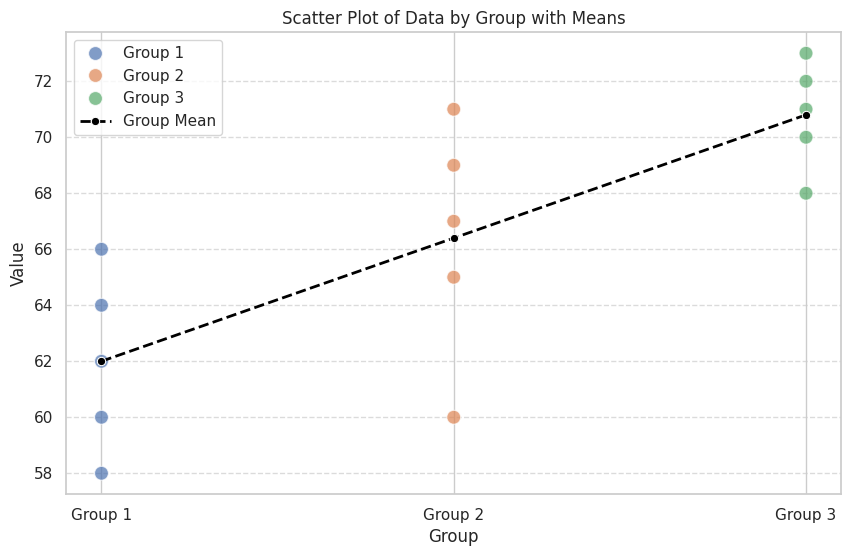

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
data = {
    'Value': group1 + group2 + group3,
    'Group': ['Group 1']*len(group1) + ['Group 2']*len(group2) + ['Group 3']*len(group3)
}
df_plot = pd.DataFrame(data)

# Calculate means for each group
group_means = df_plot.groupby('Group')['Value'].mean().reset_index()

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Group', y='Value', data=df_plot, hue='Group', s=100, alpha=0.7)
sns.lineplot(x='Group', y='Value', data=group_means, marker='o', color='black', linewidth=2, linestyle='--', label='Group Mean')

plt.title('Scatter Plot of Data by Group with Means')
plt.xlabel('Group')
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# Ensure df_plot is available (from previous visualization step)
# If running this cell independently, uncomment and run the following lines:
# data = {
#     'Value': group1 + group2 + group3,
#     'Group': ['Group 1']*len(group1) + ['Group 2']*len(group2) + ['Group 3']*len(group3)
# }
# df_plot = pd.DataFrame(data)

# Perform Tukey HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df_plot['Value'], groups=df_plot['Group'], alpha=0.05)

# Print the results
print("Tukey HSD Post-Hoc Test:")
print(tukey_result)

Tukey HSD Post-Hoc Test:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Group 1 Group 2      4.4 0.1218 -1.0675  9.8675  False
Group 1 Group 3      8.8 0.0028  3.3325 14.2675   True
Group 2 Group 3      4.4 0.1218 -1.0675  9.8675  False
------------------------------------------------------


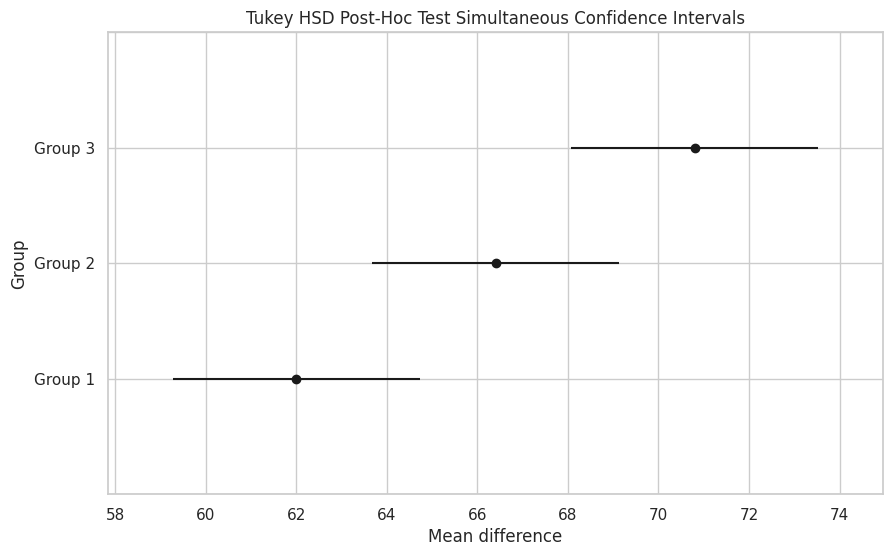

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'tukey_result' is available from the previous execution
# If not, you might need to re-run the cell where it was generated (cd18ca3e)

# Plot the Tukey HSD results
tukey_result.plot_simultaneous(ylabel="Group", xlabel="Mean difference");
plt.title('Tukey HSD Post-Hoc Test Simultaneous Confidence Intervals')
plt.show()

In [ ]:
print("Summary Statistics for df_plot:")
display(df_plot.describe())

Summary Statistics for df_plot:


,Value
count,15.000000
mean,66.400000
std,4.777925
min,58.000000
25%,63.000000
50%,67.000000
75%,70.500000
max,73.000000


In [ ]:
#two way anova

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the mtcars dataset from statsmodels datasets
mtcars = sm.datasets.get_rdataset("mtcars", "datasets").data

# Convert 'cyl' and 'gear' to categorical types (factors in R)
mtcars['cyl'] = mtcars['cyl'].astype('category')
mtcars['gear'] = mtcars['gear'].astype('category')

print("First 5 rows of mtcars dataset with categorical 'cyl' and 'gear':")
display(mtcars.head())

First 5 rows of mtcars dataset with categorical 'cyl' and 'gear':


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
print("Summary Statistics for mtcars:")
display(mtcars.describe(include='all'))

Summary Statistics for mtcars:


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.0,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0,32.0000
unique,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
top,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
freq,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,NaN
mean,20.090625,NaN,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,NaN,2.8125
std,6.026948,NaN,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,NaN,1.6152
min,10.400000,NaN,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,NaN,1.0000
25%,15.425000,NaN,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,NaN,2.0000
50%,19.200000,NaN,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,NaN,2.0000
75%,22.800000,NaN,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,NaN,4.0000


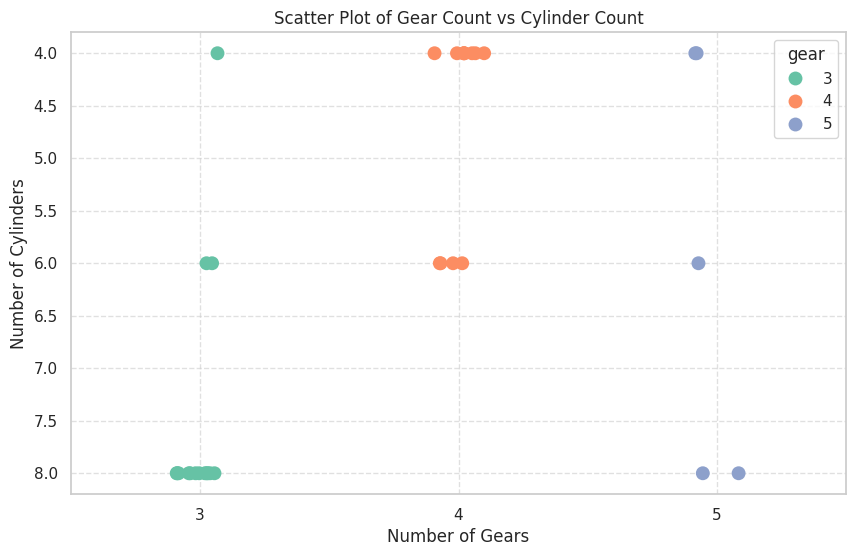

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using stripplot to handle overlapping points for categorical data
sns.stripplot(data=mtcars, x='gear', y='cyl', size=10, palette='Set2', hue='gear', jitter=True)

plt.title('Scatter Plot of Gear Count vs Cylinder Count')
plt.xlabel('Number of Gears')
plt.ylabel('Number of Cylinders')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

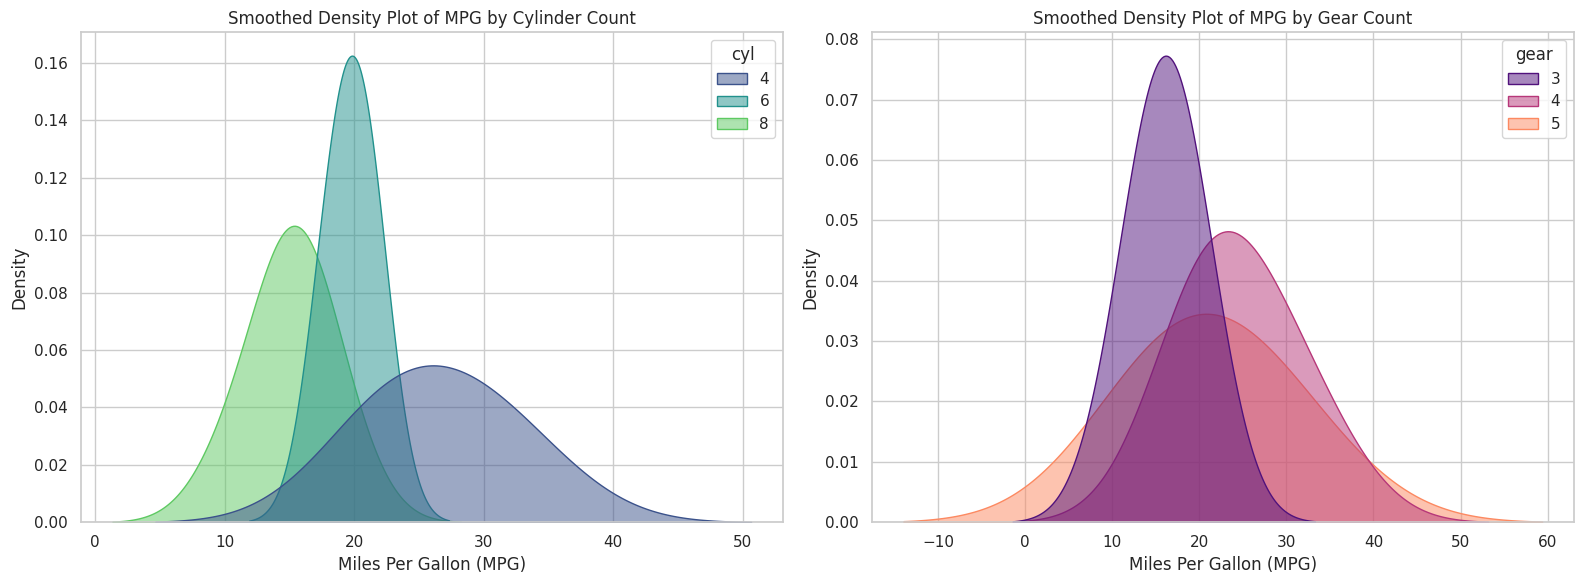

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Density plot for Cylinders with higher smoothing (bw_adjust=2.0)
sns.kdeplot(data=mtcars, x='mpg', hue='cyl', fill=True, common_norm=False, palette='viridis', alpha=0.5, ax=axes[0], bw_adjust=2.0)
axes[0].set_title('Smoothed Density Plot of MPG by Cylinder Count')
axes[0].set_xlabel('Miles Per Gallon (MPG)')

# Density plot for Gears with higher smoothing (bw_adjust=2.0)
sns.kdeplot(data=mtcars, x='mpg', hue='gear', fill=True, common_norm=False, palette='magma', alpha=0.5, ax=axes[1], bw_adjust=2.0)
axes[1].set_title('Smoothed Density Plot of MPG by Gear Count')
axes[1].set_xlabel('Miles Per Gallon (MPG)')

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

# Ensure dataset is loaded and preprocessed
mtcars = sm.datasets.get_rdataset("mtcars", "datasets").data
mtcars['cyl'] = mtcars['cyl'].astype('category')
mtcars['gear'] = mtcars['gear'].astype('category')

print(f"Unique values for 'cyl': {mtcars['cyl'].unique().tolist()}")
print(f"Unique values for 'gear': {mtcars['gear'].unique().tolist()}")

Unique values for 'cyl': [6, 4, 8]
Unique values for 'gear': [4, 3, 5]


### Perform Two-Way ANOVA
We will use `statsmodels.formula.api.ols` to define the model and then `sm.stats.anova_lm` to get the ANOVA table. The formula `mpg ~ C(cyl) * C(gear)` specifies that `mpg` is the dependent variable, and `cyl` and `gear` are independent variables, with an interaction term.

In [ ]:
# Perform Two-Way ANOVA
# C() explicitly tells statsmodels to treat the variable as categorical
anova_model = ols('mpg ~ C(cyl) * C(gear)', data=mtcars).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2) # Type 2 ANOVA for unbalanced designs

print("\nTwo-Way ANOVA Results:")
display(anova_table)


Two-Way ANOVA Results:


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(cyl),6.222698,2.0,0.277469,0.603200
C(gear),0.763675,2.0,0.034052,0.855146
C(cyl):C(gear),31.854324,4.0,0.710189,0.555411
Residual,269.120000,24.0,NaN,NaN


### Post-hoc analysis using Tukey's HSD test
Since the ANOVA showed significant main effects or interaction, we perform a post-hoc test to see which specific group means differ. We will analyze the interaction effects if the interaction term is significant, otherwise we can look at main effects.


Tukey's HSD Post-Hoc Test for Interaction (cyl:gear):
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
   4:3    4:4    5.425 0.7857  -6.3381 17.1881  False
   4:3    4:5      6.7 0.7265  -6.8829 20.2829  False
   4:3    6:3    -1.75 0.9998 -15.3329 11.8329  False
   4:3    6:4    -1.75 0.9997 -14.1494 10.6494  False
   4:3    6:5     -1.8 0.9999 -17.4842 13.8842  False
   4:3    8:3    -6.45 0.5945 -17.9932  5.0932  False
   4:3    8:5     -6.1 0.8065 -19.6829  7.4829  False
   4:4    4:5    1.275 0.9997  -7.4927 10.0427  False
   4:4    6:3   -7.175 0.1675 -15.9427  1.5927  False
   4:4    6:4   -7.175 0.0332 -13.9664 -0.3836   True
   4:4    6:5   -7.225 0.4814 -18.9881  4.5381  False
   4:4    8:3  -11.875    0.0  -16.937  -6.813   True
   4:4    8:5  -11.525 0.0045 -20.2927 -2.7573   True
   4:5    6:3    -8.45  0.233 -19.5404  2.6404  False
   4:5    6:4    -8.45 0.11

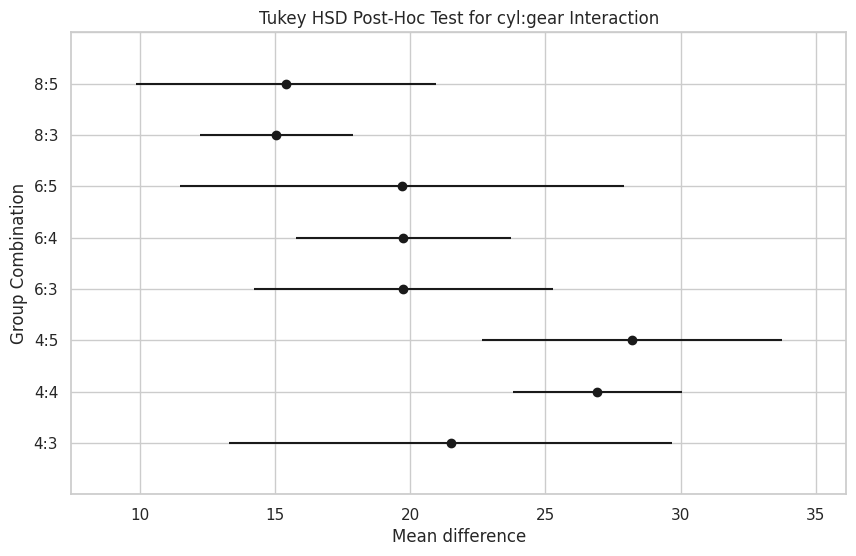

In [ ]:
# To perform Tukey HSD on interaction effects, we need to create a combined group variable
mtcars['cyl_gear_group'] = mtcars['cyl'].astype(str) + ':' + mtcars['gear'].astype(str)

print("\nTukey's HSD Post-Hoc Test for Interaction (cyl:gear):")
tukey_results_interaction = pairwise_tukeyhsd(endog=mtcars['mpg'], groups=mtcars['cyl_gear_group'], alpha=0.05)
print(tukey_results_interaction)

# Plot the Tukey HSD results for interaction
tukey_results_interaction.plot_simultaneous(xlabel='Mean difference', ylabel='Group Combination');
plt.title('Tukey HSD Post-Hoc Test for cyl:gear Interaction')
plt.show()

# If interaction is not significant, one might also look at main effects if they were significant in ANOVA
# Example for main effect of 'cyl' if interaction was not significant
# print("\nTukey's HSD Post-Hoc Test for Main Effect of Cyl:")
# tukey_results_cyl = pairwise_tukeyhsd(endog=mtcars['mpg'], groups=mtcars['cyl'], alpha=0.05)
# print(tukey_results_cyl)
# tukey_results_cyl.plot_simultaneous(xlabel='Mean difference', ylabel='Cylinders');
# plt.title('Tukey HSD Post-Hoc Test for Main Effect of Cyl')
# plt.show()


### Assumption Checks for ANOVA
ANOVA relies on certain assumptions:
1.  **Normality of residuals:** The residuals (the differences between observed and predicted values) should be approximately normally distributed.
2.  **Homogeneity of variance (Homoscedasticity):** The variance of residuals should be roughly equal across all groups.



Shapiro-Wilk Test for Normality of Residuals:
Statistic = 0.978, p-value = 0.726
Conclusion: Residuals appear normally distributed (Fail to reject H0).

Levene's Test for Homogeneity of Variance:
Statistic = 2.193, p-value = 0.072
Conclusion: Variances appear homogeneous (Fail to reject H0).


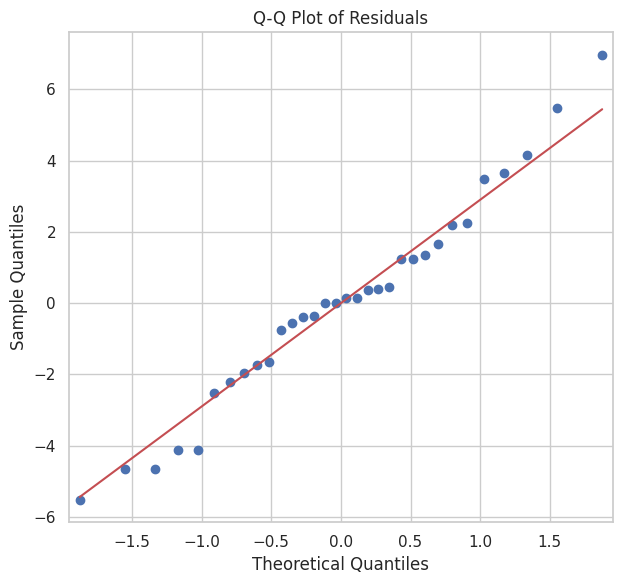

In [ ]:
# 1. Normality of residuals (Q-Q plot)
residuals = anova_model.resid

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

# Shapiro-Wilk Test for normality (more formal test)
shapiro_test = stats.shapiro(residuals)
print(f"\nShapiro-Wilk Test for Normality of Residuals:\nStatistic = {shapiro_test.statistic:.3f}, p-value = {shapiro_test.pvalue:.3f}")
if shapiro_test.pvalue < 0.05:
    print("Conclusion: Residuals are not normally distributed (Reject H0).")
else:
    print("Conclusion: Residuals appear normally distributed (Fail to reject H0).")

# 2. Levene's Test for Homogeneity of Variance
# We need to extract residuals for each group combination
groups = mtcars['cyl_gear_group'].unique()
residuals_per_group = [residuals[mtcars['cyl_gear_group'] == g] for g in groups]

levene_test = stats.levene(*residuals_per_group)
print(f"\nLevene's Test for Homogeneity of Variance:\nStatistic = {levene_test.statistic:.3f}, p-value = {levene_test.pvalue:.3f}")
if levene_test.pvalue < 0.05:
    print("Conclusion: Variances are not homogeneous (Reject H0).")
else:
    print("Conclusion: Variances appear homogeneous (Fail to reject H0).")

plt.tight_layout()
plt.show()